# DIS SP26 Final Project: NLP-aided Classification for Predicting Russian Troll Strategy Shift around the 2016 US Presidential Election.

## Import statements

In [ ]:
import pandas as pd 
import nltk
import re
import matplotlib.pyplot as plt
import sklearn
import textstat
from transformers import pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Data Loading and Cleaning

In [104]:
# Does not need to be run again, but here is the code that was used to download the data from the original source.
#
# import os
# import urllib.request

# DATA_DIR = "data"
# BASE_URL = "https://raw.githubusercontent.com/fivethirtyeight/russian-troll-tweets/master"

# os.makedirs(DATA_DIR, exist_ok=True)

# for i in range(1, 13):
#     filename = f"IRAhandle_tweets_{i}.csv"
#     local_path = os.path.join(DATA_DIR, filename)
#     if os.path.exists(local_path):
#         print(f"already have {filename}")
#         continue
#     print(f"downloading {filename}...")
#     urllib.request.urlretrieve(f"{BASE_URL}/{filename}", local_path)

# print("done")

In [105]:
#I rewrote this logic so that we do not need to rescrape each time. 
#It should work as long as you are working in the proper directory
frames = []
for i in range(1, 13):
        frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))

df = pd.concat(frames, ignore_index=True)
df.head()

/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_63292/3869175660.py:5: DtypeWarning: Columns (0,15,20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))
/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_63292/3869175660.py:5: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))
/var/folders/gg/vzk6qfcs4737tbz1k864_q040000gn/T/ipykernel_63292/3869175660.py:5: DtypeWarning: Columns (10,20) have mixed types. Specify dtype option on import or set low_memory=False.
  frames.append(pd.read_csv(f"data/IRAhandle_tweets_{i}.csv"))


,external_author_id,author,content,region,language,publish_date,harvested_date,following,followers,updates,...,account_type,retweet,account_category,new_june_2018,alt_external_id,tweet_id,article_url,tco1_step1,tco2_step1,tco3_step1
0,906000000000000000,10_GOP,"""We have a sitting Democrat US Senator on tria...",Unknown,English,10/1/2017 19:58,10/1/2017 19:59,1052,9636,253,...,Right,0,RightTroll,0,905874659358453760,914580356430536707,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/914580356430...,NaN,NaN
1,906000000000000000,10_GOP,Marshawn Lynch arrives to game in anti-Trump s...,Unknown,English,10/1/2017 22:43,10/1/2017 22:43,1054,9637,254,...,Right,0,RightTroll,0,905874659358453760,914621840496189440,http://twitter.com/905874659358453760/statuses...,https://twitter.com/damienwoody/status/9145685...,NaN,NaN
2,906000000000000000,10_GOP,Daughter of fallen Navy Sailor delivers powerf...,Unknown,English,10/1/2017 22:50,10/1/2017 22:51,1054,9637,255,...,Right,1,RightTroll,0,905874659358453760,914623490375979008,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/913231923715...,NaN,NaN
3,906000000000000000,10_GOP,JUST IN: President Trump dedicates Presidents ...,Unknown,English,10/1/2017 23:52,10/1/2017 23:52,1062,9642,256,...,Right,0,RightTroll,0,905874659358453760,914639143690555392,http://twitter.com/905874659358453760/statuses...,https://twitter.com/10_gop/status/914639143690...,NaN,NaN
4,906000000000000000,10_GOP,"19,000 RESPECTING our National Anthem! #StandF...",Unknown,English,10/1/2017 2:13,10/1/2017 2:13,1050,9645,246,...,Right,1,RightTroll,0,905874659358453760,914312219952861184,http://twitter.com/905874659358453760/statuses...,https://twitter.com/realDonaldTrump/status/914...,NaN,NaN


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925313 entries, 0 to 2925312
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   external_author_id  object
 1   author              object
 2   content             object
 3   region              object
 4   language            object
 5   publish_date        object
 6   harvested_date      object
 7   following           int64 
 8   followers           int64 
 9   updates             int64 
 10  post_type           object
 11  account_type        object
 12  retweet             int64 
 13  account_category    object
 14  new_june_2018       int64 
 15  alt_external_id     object
 16  tweet_id            int64 
 17  article_url         object
 18  tco1_step1          object
 19  tco2_step1          object
 20  tco3_step1          object
dtypes: int64(6), object(15)
memory usage: 468.7+ MB


In [107]:
# Columns that serve no modelling purpose and are dropped throughout
DROP_COLS = ["tweet_id", "alt_external_id", "article_url",
             "tco1_step1", "tco2_step1", "tco3_step1",
             "new_june_2018", "external_author_id", "harvested_date"]

# Data cleaning and feature engineering
cleaned_df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
cleaned_df.replace({"post_type": {None: "TWEET"}}, inplace=True)

# Type casting
cleaned_df["author"] = cleaned_df["author"].astype(str) 
cleaned_df["content"] = cleaned_df["content"].astype(str) 
cleaned_df["region"] = cleaned_df["region"].astype(str)
cleaned_df["language"] = cleaned_df["language"].astype(str)
cleaned_df["account_category"] = cleaned_df["account_category"].astype(str)

# Date formatting and scaling
cleaned_df["publish_date"] = pd.to_datetime(cleaned_df["publish_date"], format="mixed", errors="coerce")

def scale_around_midpoint(series, min_date, mid_date, max_date):
    return series.apply(
        lambda x: (x - mid_date) / (mid_date - min_date) if x < mid_date
                  else (x - mid_date) / (max_date - mid_date)
    )

cleaned_df["publish_date"] = scale_around_midpoint(
    cleaned_df["publish_date"],
    min_date=cleaned_df["publish_date"].min(),
    mid_date=pd.to_datetime("2016-11-08"),
    max_date=cleaned_df["publish_date"].max(),
)

# Select the English language tweets for our purposes
english_df = cleaned_df[cleaned_df["language"] == "English"].copy()
english_df = english_df.sample(frac=0.25, random_state=67).copy()

# Clean the tweets using regex
_rt_prefix = re.compile(r"^RT @\w+:\s*")
_url = re.compile(r"https?://\S+|www\.\S+")

def clean_tweet(text):
    text = _rt_prefix.sub("", text)
    text = _url.sub("", text)
    return text.strip()

english_df["content_clean"] = english_df["content"].map(clean_tweet)

## EDA

In [108]:
cleaned_df["post_type"].groupby(cleaned_df["post_type"]).count()

post_type
QUOTE_TWEET      39938
RETWEET        1239753
TWEET          1645622
Name: post_type, dtype: int64

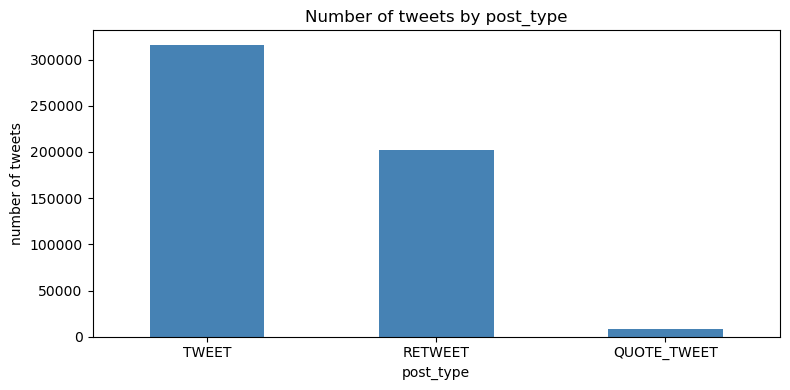

In [109]:
post_type_counts = english_df["post_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
post_type_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of tweets by post_type")
ax.set_xlabel("post_type")
ax.set_ylabel("number of tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

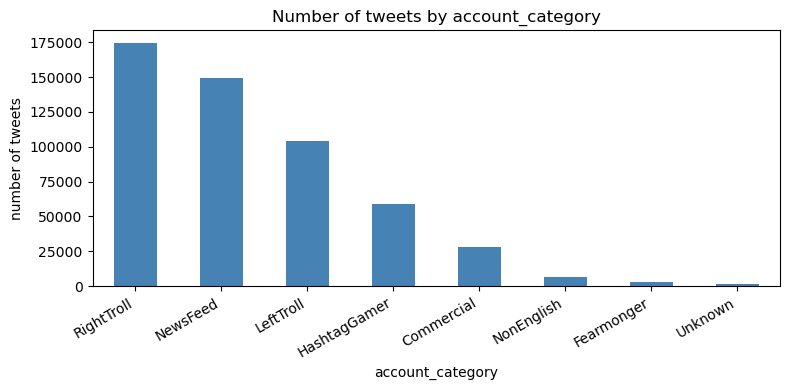

In [110]:
account_category_counts = english_df["account_category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
account_category_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of tweets by account_category")
ax.set_xlabel("account_category")
ax.set_ylabel("number of tweets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

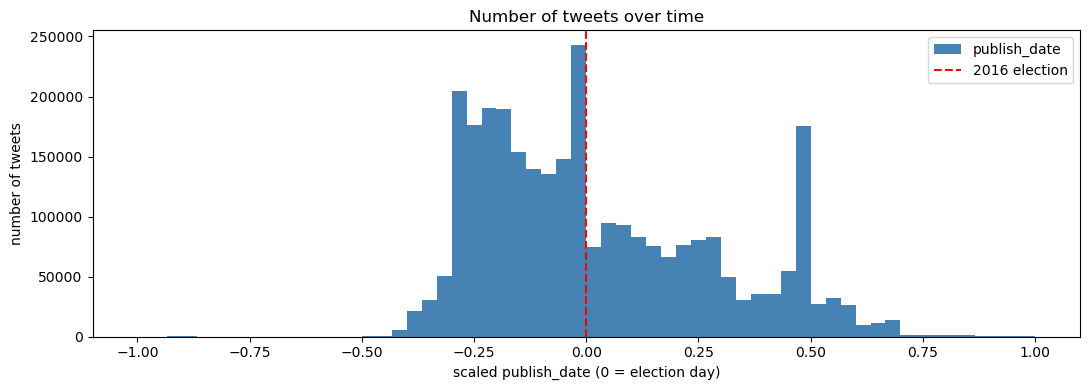

In [111]:
fig, ax = plt.subplots(figsize=(11, 4))
cleaned_df["publish_date"].plot(kind="hist", bins=60, ax=ax, color="steelblue")
ax.axvline(0, color="red", linestyle="--", label="2016 election")
ax.set_title("Number of tweets over time")
ax.set_xlabel("scaled publish_date (0 = election day)")
ax.set_ylabel("number of tweets")
ax.legend()
plt.tight_layout()
plt.show()

In [112]:
cleaned_df["region"].groupby(cleaned_df["region"]).count()

region
Afghanistan                     3318
Austria                            1
Azerbaijan                     94916
Belarus                        27335
Canada                           608
Czech Republic                     7
Denmark                            1
Egypt                            232
Estonia                            1
Finland                           20
France                           942
Germany                        27178
Greece                            81
Hong Kong                          3
India                             22
Iran, Islamic Republic of        541
Iraq                           11117
Israel                          3604
Italy                          13474
Japan                            108
Latvia                             7
Malaysia                        4932
Mexico                            41
Russian Federation             37052
Samoa                             32
Saudi Arabia                      55
Serbia                         

In [113]:
count = (cleaned_df["publish_date"] >= 0).astype(int)
count.value_counts()

publish_date
0    1689047
1    1236266
Name: count, dtype: int64

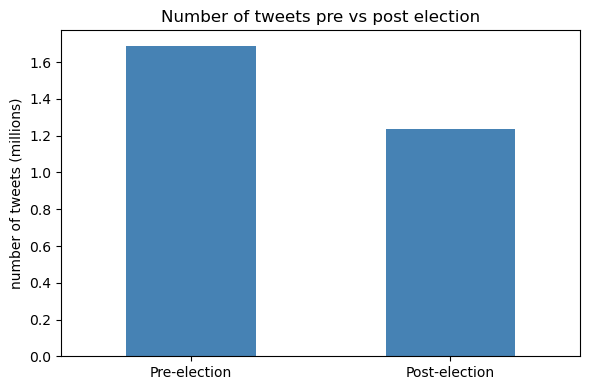

In [114]:
post_election_counts = (cleaned_df["publish_date"] >= 0).map({False: "Pre-election", True: "Post-election"}).value_counts() / 1_000_000

fig, ax = plt.subplots(figsize=(6, 4))
post_election_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of tweets pre vs post election")
ax.set_xlabel("")
ax.set_ylabel("number of tweets (millions)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature Engineering

### VADER Sentiment

In [115]:
from tqdm.auto import tqdm
tqdm.pandas(desc="VADER")

nltk.download("vader_lexicon", quiet=True)

sia = SentimentIntensityAnalyzer()

scores = english_df["content_clean"].progress_map(sia.polarity_scores)
scores_df = pd.DataFrame(scores.tolist(), index=english_df.index)
scores_df.columns = ["sent_neg", "sent_neu", "sent_pos", "sent_compound"]

english_df = pd.concat([english_df, scores_df], axis=1)
english_df[["content_clean", "sent_neg", "sent_neu", "sent_pos", "sent_compound"]].head()

VADER:   0%|          | 0/526316 [00:00<?, ?it/s]

,content_clean,sent_neg,sent_neu,sent_pos,sent_compound
420191,"Who sets my course, Determines my values, My r...",0.180,0.640,0.18,0.0000
1495424,#news Legislation limiting who could serve on ...,0.203,0.797,0.00,-0.4215
2326526,Appeal hearing for NFL's Brady begins in New Y...,0.000,1.000,0.00,0.0000
710825,Woman dies after being hit by a truck in Torrance,0.000,1.000,0.00,0.0000
662267,Al Franked must resign immediately #ResignAl,0.324,0.676,0.00,-0.3400


In [116]:
english_df["sent_compound"].describe()

count    526316.000000
mean         -0.039634
std           0.418344
min          -0.994500
25%          -0.340000
50%           0.000000
75%           0.202300
max           0.999100
Name: sent_compound, dtype: float64

In [117]:
english_df.groupby("account_category")["sent_compound"].agg(["mean", "std", "count"]).sort_values("mean")

,mean,std,count
account_category,,,
NewsFeed,-0.119473,0.391177,149081
RightTroll,-0.052576,0.444997,174869
Fearmonger,-0.024555,0.435855,2664
LeftTroll,0.025090,0.437267,104158
HashtagGamer,0.030042,0.366983,58838
NonEnglish,0.035640,0.410415,6520
Commercial,0.050344,0.319425,28385
Unknown,0.093317,0.429255,1801


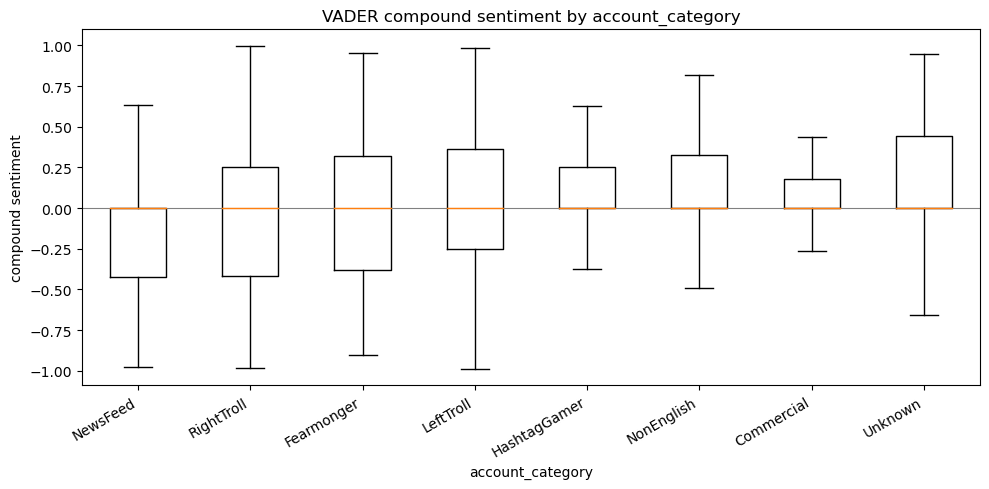

In [118]:
order = english_df.groupby("account_category")["sent_compound"].mean().sort_values().index
data = [english_df.loc[english_df["account_category"] == cat, "sent_compound"].values for cat in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, labels=order, vert=True, showfliers=False)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("VADER compound sentiment by account_category")
ax.set_xlabel("account_category")
ax.set_ylabel("compound sentiment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

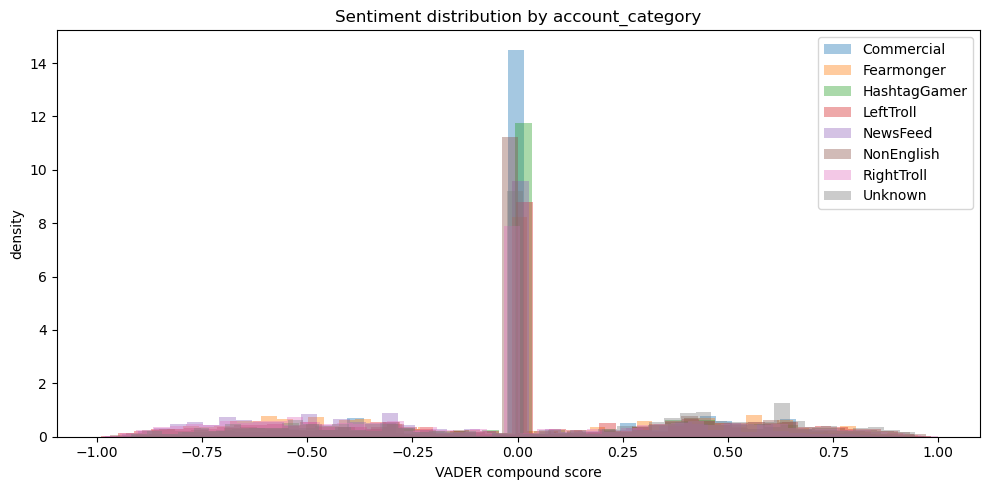

In [119]:
fig, ax = plt.subplots(figsize=(10, 5))
for cat, grp in english_df.groupby("account_category"):
    grp["sent_compound"].plot(kind="hist", bins=50, alpha=0.4, label=cat, ax=ax, density=True)
ax.set_xlabel("VADER compound score")
ax.set_ylabel("density")
ax.set_title("Sentiment distribution by account_category")
ax.legend()
plt.tight_layout()
plt.show()

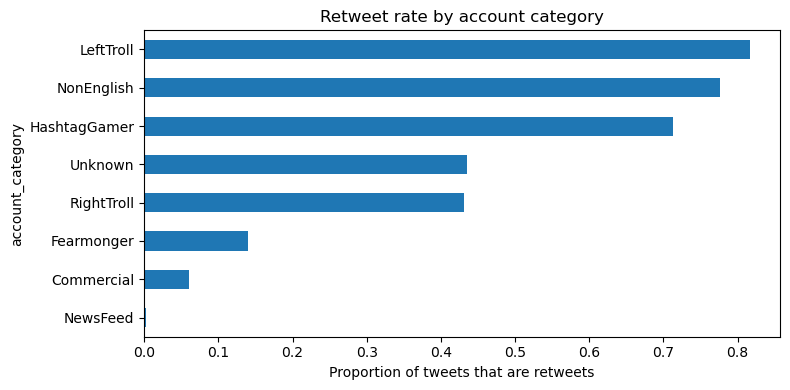

In [120]:
fig, ax = plt.subplots(figsize=(8, 4))
(
    english_df.groupby("account_category")["retweet"]
    .mean()
    .sort_values()
    .plot(kind="barh", ax=ax)
)
ax.set_title("Retweet rate by account category")
ax.set_xlabel("Proportion of tweets that are retweets")
plt.tight_layout()
plt.show()

### Additional NLP Features

Adding new feature columns to "english_df" here before building "features_df".

In [121]:
# Hashtag use might indicate useful information.
english_df["hashtag_count"] = english_df["content"].str.count("#")
english_df["follower_ratio"] = english_df["followers"] / (english_df["following"] + 1)
english_df["updates_per_follower_ratio"] = english_df["updates"] / (english_df["followers"] + 1)
# Flesch reading score for how easy the tweet is to read
english_df["flesch_ease"] = english_df["content_clean"].map(
    textstat.flesch_reading_ease
)
# Flesch score for approximate US grade level in reading
english_df["flesch_kincaid_grade"] = english_df["content_clean"].map(
    textstat.flesch_kincaid_grade
)

In [122]:
english_df.describe()

,publish_date,following,followers,updates,retweet,sent_neg,sent_neu,sent_pos,sent_compound,hashtag_count,follower_ratio,updates_per_follower_ratio,flesch_ease,flesch_kincaid_grade
count,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000,526316.000000
mean,0.043871,4244.592376,7142.419079,11333.343641,0.399986,0.110007,0.798153,0.090169,-0.039634,0.688619,10.151659,14.253220,51.750126,8.555666
std,0.268311,6270.959968,11642.765399,19203.624501,0.489896,0.156916,0.191481,0.143269,0.418344,1.024435,253.813359,55.367649,33.428922,4.684611
min,-0.996242,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-0.994500,0.000000,0.000000,0.000087,-1993.780000,-3.400000
25%,-0.161056,605.000000,633.000000,1705.000000,0.000000,0.000000,0.667000,0.000000,-0.340000,0.000000,0.802207,1.021594,35.945000,5.682857
50%,-0.018467,2030.000000,1861.000000,4694.000000,0.000000,0.000000,0.805000,0.000000,0.000000,0.000000,1.159057,1.993907,56.250000,8.350000
75%,0.229953,5723.000000,12303.000000,14198.000000,1.000000,0.211000,1.000000,0.169000,0.202300,1.000000,2.123539,5.095782,72.615455,11.072632
max,0.999996,76210.000000,206686.000000,166082.000000,1.000000,1.000000,1.000000,1.000000,0.999100,23.000000,90699.000000,5962.000000,127.215714,291.600000


In [123]:
english_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 526316 entries, 420191 to 511535
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   author                      526316 non-null  object 
 1   content                     526316 non-null  object 
 2   region                      526316 non-null  object 
 3   language                    526316 non-null  object 
 4   publish_date                526316 non-null  float64
 5   following                   526316 non-null  int64  
 6   followers                   526316 non-null  int64  
 7   updates                     526316 non-null  int64  
 8   post_type                   526316 non-null  object 
 9   account_type                526316 non-null  object 
 10  retweet                     526316 non-null  int64  
 11  account_category            526316 non-null  object 
 12  content_clean               526316 non-null  object 
 13  sent_neg      

In [124]:
english_df.head()

,author,content,region,language,publish_date,following,followers,updates,post_type,account_type,...,content_clean,sent_neg,sent_neu,sent_pos,sent_compound,hashtag_count,follower_ratio,updates_per_follower_ratio,flesch_ease,flesch_kincaid_grade
420191,BRIANTHELIFTER,"Who sets my course, Determines my values, My r...",United States,English,0.197165,520,836,3744,RETWEET,Left,...,"Who sets my course, Determines my values, My r...",0.180,0.640,0.18,0.0000,0,1.604607,4.473118,73.172000,9.264000
1495424,KANSASDAILYNEWS,#news Legislation limiting who could serve on ...,United States,English,-0.187762,6952,22358,25426,TWEET,local,...,#news Legislation limiting who could serve on ...,0.203,0.797,0.00,-0.4215,1,3.215590,1.137171,60.705000,7.773333
2326526,ROOMOFRUMOR,Appeal hearing for NFL's Brady begins in New Y...,United States,English,-0.289151,6025,11908,3597,TWEET,news,...,Appeal hearing for NFL's Brady begins in New Y...,0.000,1.000,0.00,0.0000,1,1.976104,0.302040,60.634286,10.019048
710825,DAILYLOSANGELES,Woman dies after being hit by a truck in Torra...,United States,English,0.202071,6308,17906,11851,TWEET,local,...,Woman dies after being hit by a truck in Torrance,0.000,1.000,0.00,0.0000,0,2.838168,0.661808,78.245000,4.830000
662267,COVFEFENATIONUS,Al Franked must resign immediately #ResignAl h...,United States,English,0.657862,248,2223,148186,RETWEET,Right,...,Al Franked must resign immediately #ResignAl,0.324,0.676,0.00,-0.3400,1,8.927711,66.630396,17.445000,12.316667


In [125]:
for cat in english_df["account_category"].unique():
    sub = english_df[english_df["account_category"] == cat]
    print(f"\n=== {cat} ===")
    print("most positive:", sub.loc[sub["sent_compound"].idxmax(), "content_clean"][:140])
    print("most negative:", sub.loc[sub["sent_compound"].idxmin(), "content_clean"][:140])


=== LeftTroll ===
most positive: A goal &amp; an assist but most important is a great win by the team ✌ congrats to peterborough and good luck for the season�#cfc #jobdone
most negative: stop the war stop the war stop the war stop the war stop the war stop the war #EndYemenWar they don't know no love

=== NewsFeed ===
most positive: FORECAST \| Terrific Weather Tuesday!: More bright, beautiful sunshine and pleasant temperatur...  #Cleveland #news
most negative: Cleveland rapist pleads guilty to another rape and murder of Michaela Diemer: A convicted rapist pleaded guilty Tuesday to the...  #crime

=== RightTroll ===
most positive: We win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we win, we w
most negative: Kill, kill, kill, kill, kill, kill  #America

=== HashtagGamer ===
most positive: Happy Sunday Sweet Friends  It's a Gorgeous Day, Life is Wonderful .. Enjoy Every Moment! Love & Happiness 2 All �
most ne

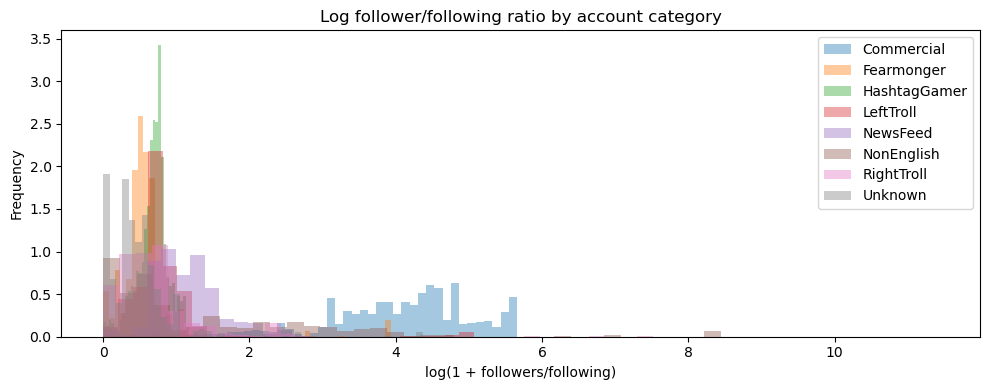

In [126]:
fig, ax = plt.subplots(figsize=(10, 4))
for cat, grp in english_df.groupby("account_category"):
    np.log1p(grp["follower_ratio"]).plot(
        kind="hist", bins=50, alpha=0.4, density=True, label=cat, ax=ax
    )
ax.set_title("Log follower/following ratio by account category")
ax.set_xlabel("log(1 + followers/following)")
ax.legend()
plt.tight_layout()
plt.show()


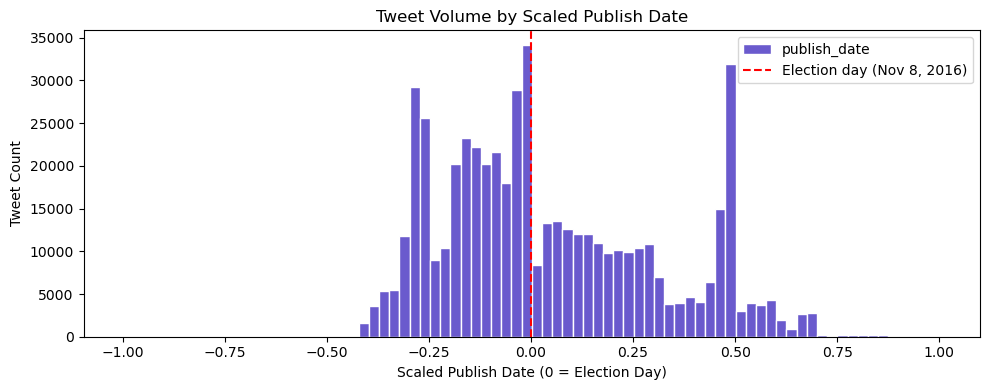

In [127]:
# Tweet Volume Over Time
plot_df = english_df.copy()
plot_df["pre_post"] = (plot_df["publish_date"] >= 0).map({0: "Pre-election", 1: "Post-election"})

fig, ax = plt.subplots(figsize=(10, 4))
plot_df["publish_date"].plot(kind="hist", bins=80, ax=ax, color="slateblue", edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Election day (Nov 8, 2016)")
ax.set_title("Tweet Volume by Scaled Publish Date")
ax.set_xlabel("Scaled Publish Date (0 = Election Day)")
ax.set_ylabel("Tweet Count")
ax.legend()
plt.tight_layout()
plt.show()

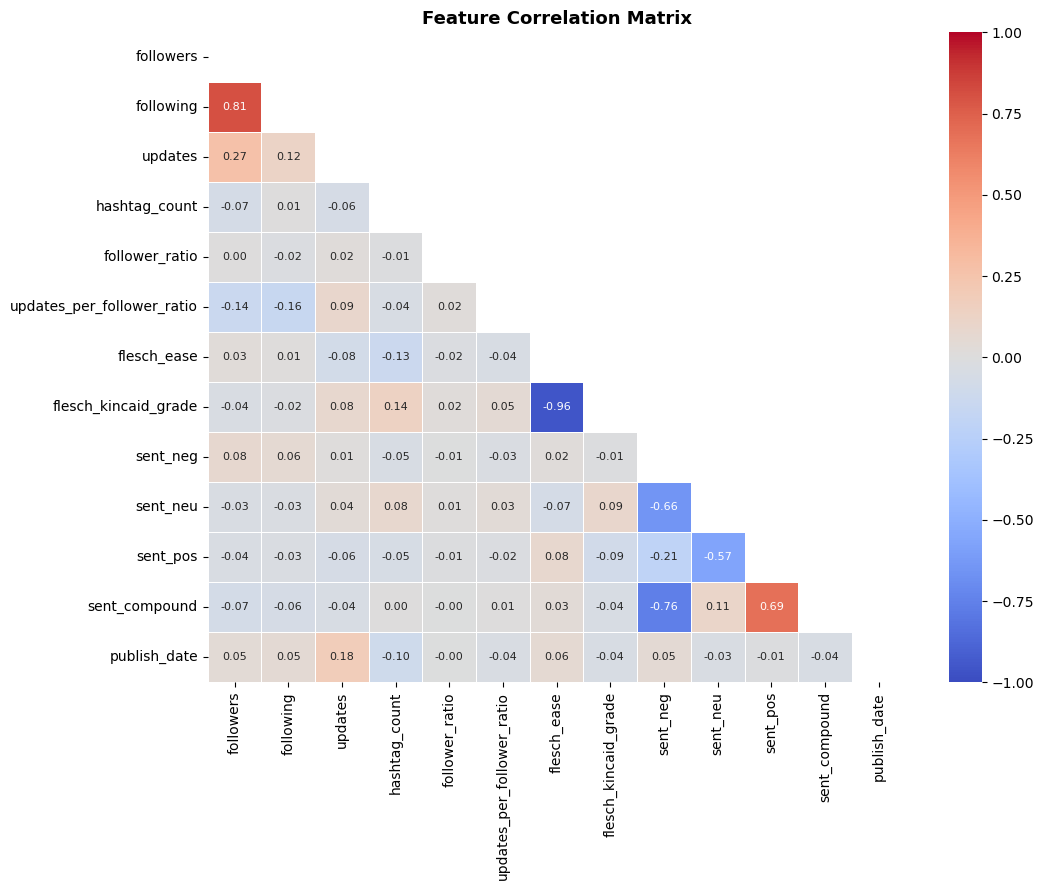

In [128]:
# Correlation Heatmap of Numeric Features

corr_cols = ["followers", "following", "updates", "hashtag_count",
             "follower_ratio", "updates_per_follower_ratio",
             "flesch_ease", "flesch_kincaid_grade",
             "sent_neg", "sent_neu", "sent_pos", "sent_compound", "publish_date"]

corr_df = english_df[[c for c in corr_cols if c in english_df.columns]].copy()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle (redundant)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Modelling

### Feature Matrix

In [129]:
KEEP_COLS = [
    "author",     # Column used for group-aware split     
    "publish_date",    
    "following",
    "followers",
    "updates",
    "post_type",
    "account_type",
    "retweet",
    "hashtag_count",
    "follower_ratio",
    "updates_per_follower_ratio",
    "flesch_ease",
    "flesch_kincaid_grade",
    "sent_neg",
    "sent_neu",
    "sent_pos",
    "sent_compound",
    "account_category",
]

features_df = english_df[KEEP_COLS].copy()
features_df.head()

,author,publish_date,following,followers,updates,post_type,account_type,retweet,hashtag_count,follower_ratio,updates_per_follower_ratio,flesch_ease,flesch_kincaid_grade,sent_neg,sent_neu,sent_pos,sent_compound,account_category
420191,BRIANTHELIFTER,0.197165,520,836,3744,RETWEET,Left,1,0,1.604607,4.473118,73.172000,9.264000,0.180,0.640,0.18,0.0000,LeftTroll
1495424,KANSASDAILYNEWS,-0.187762,6952,22358,25426,TWEET,local,0,1,3.215590,1.137171,60.705000,7.773333,0.203,0.797,0.00,-0.4215,NewsFeed
2326526,ROOMOFRUMOR,-0.289151,6025,11908,3597,TWEET,news,0,1,1.976104,0.302040,60.634286,10.019048,0.000,1.000,0.00,0.0000,NewsFeed
710825,DAILYLOSANGELES,0.202071,6308,17906,11851,TWEET,local,0,0,2.838168,0.661808,78.245000,4.830000,0.000,1.000,0.00,0.0000,NewsFeed
662267,COVFEFENATIONUS,0.657862,248,2223,148186,RETWEET,Right,1,1,8.927711,66.630396,17.445000,12.316667,0.324,0.676,0.00,-0.3400,RightTroll


In [130]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 526316 entries, 420191 to 511535
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   author                      526316 non-null  object 
 1   publish_date                526316 non-null  float64
 2   following                   526316 non-null  int64  
 3   followers                   526316 non-null  int64  
 4   updates                     526316 non-null  int64  
 5   post_type                   526316 non-null  object 
 6   account_type                526316 non-null  object 
 7   retweet                     526316 non-null  int64  
 8   hashtag_count               526316 non-null  int64  
 9   follower_ratio              526316 non-null  float64
 10  updates_per_follower_ratio  526316 non-null  float64
 11  flesch_ease                 526316 non-null  float64
 12  flesch_kincaid_grade        526316 non-null  float64
 13  sent_neg      

### Training & Evaluation

In [131]:
#Flawed split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

y = (features_df["publish_date"] >= 0).astype(int)
X = features_df.drop(columns=["publish_date", "author"])
X = pd.get_dummies(X, columns=["post_type", "account_type", "account_category"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=67)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

accuracy: 0.9893
              precision    recall  f1-score   support

           0     0.9896    0.9911    0.9903     57962
           1     0.9890    0.9872    0.9881     47302

    accuracy                         0.9893    105264
   macro avg     0.9893    0.9891    0.9892    105264
weighted avg     0.9893    0.9893    0.9893    105264



In [132]:
#Proper split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report

y = (features_df["publish_date"] >= 0).astype(int)
X = features_df.drop(columns=["publish_date", "author"])
X = pd.get_dummies(X, columns=["post_type", "account_type", "account_category"])

groups = features_df["author"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=67)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

accuracy: 0.8433
              precision    recall  f1-score   support

           0     0.8415    0.8690    0.8550     65945
           1     0.8456    0.8142    0.8296     58099

    accuracy                         0.8433    124044
   macro avg     0.8435    0.8416    0.8423    124044
weighted avg     0.8434    0.8433    0.8431    124044



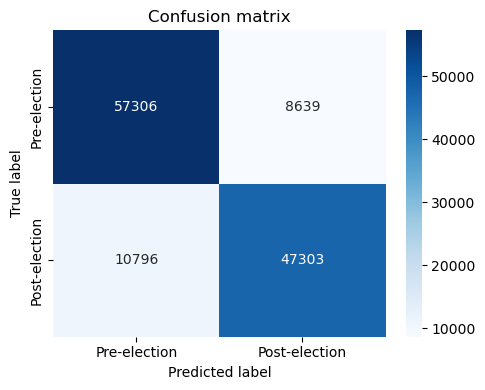

In [133]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pre-election", "Post-election"],
    yticklabels=["Pre-election", "Post-election"],
    ax=ax
)
ax.set_title("Confusion matrix")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.show()

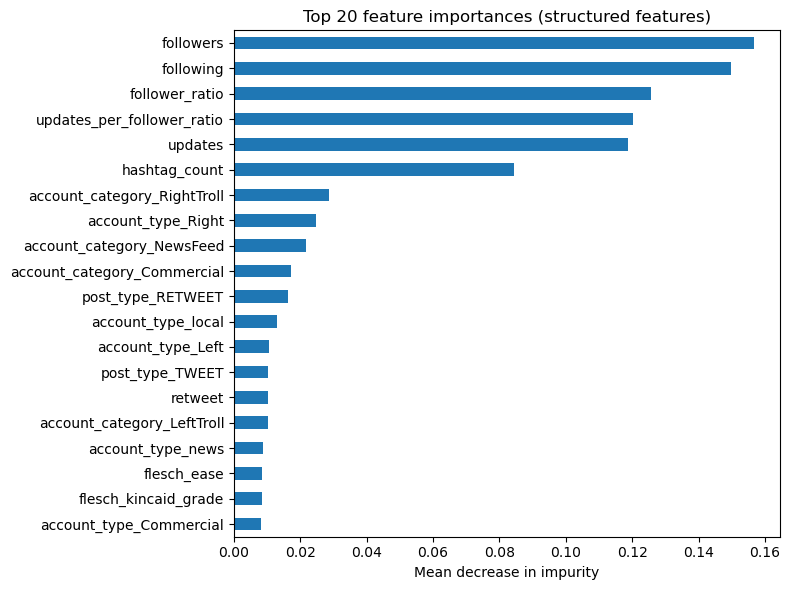

In [134]:
importances = pd.Series(
    clf.feature_importances_,
    index=X_train.columns  
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Top 20 feature importances (structured features)")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

In [136]:
# Hyperparameter Tuning with RandomizedSearchCV
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV

# Use grouped CV so the same author can't appear in both inner train and val folds
groups_train = features_df.loc[X_train.index, "author"]
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
base_clf = RandomForestClassifier(n_jobs=1, random_state=67)

param_dist = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
    "class_weight":      [None, "balanced"],
}

search = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param_dist,
    n_iter=15,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)
# Pass groups so the splitter actually applies author-aware folds
search.fit(X_train, y_train, groups=groups_train)

print("Best parameters found:")
print(search.best_params_)
print(f"\nBest CV accuracy: {search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters found:
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'class_weight': None}

Best CV F1 (weighted): 0.8693
